In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from mphsweepkit.plot_data import DataPlot
import matplotlib.pyplot as plt

In [ ]:
# 1) Load result data exported by CascadedSweepModel.save_result_data(...)
result_dir = Path("result_data")  # adjust if needed
dp = DataPlot.from_result_folder(result_dir)

# 2) Inspect loaded data
print("Input shape:", dp.input_df.shape)
print("Output shape:", dp.output_df.shape)
print("Combined shape:", dp.combined_df.shape)

print("\nInput columns:", dp.input_columns())
print("Output columns:", dp.output_columns())

# 3) Access metadata
y_col = dp.output_columns()[0]
print(f"\nSelected output column: {y_col}")
print("Label:", dp.get_label(y_col))
print("Unit:", dp.get_unit(y_col))
print("Axis label:", dp.format_axis_label(y_col))

# 4) Access combined dataframe
display(dp.combined_df.head())

Input shape: (156, 8)
Output shape: (156, 3)
Combined shape: (156, 11)

Input columns: ['hor_slit', 'vert_slit', 'w', 'l_r', 'a_e', 'matsw.comp1.core', 'b_mean', 'freq']
Output columns: ['p_loss', 'p_mag', 'p_el']

Selected output column: p_loss
Label: $p_\mathrm{loss}$
Unit: W /m^3
Axis label: $p_\mathrm{loss}$ [W /m^3]


,hor_slit,vert_slit,w,l_r,a_e,matsw.comp1.core,b_mean,freq,p_loss,p_mag,p_el
0,0.0,0.0,5.0,0.0,5.0,2.0,25.0,100.0,1065.208505,1016.230503,48.978002
1,0.0,0.0,5.0,0.0,5.0,2.0,25.0,200.0,2817.933228,2542.728371,275.204857
2,0.0,0.0,5.0,0.0,5.0,2.0,25.0,300.0,5421.142527,4629.192329,791.950198
3,0.0,0.0,5.0,0.0,5.0,2.0,25.0,400.0,9291.744486,7584.088889,1707.655596
4,0.0,0.0,5.0,0.0,5.0,2.0,25.0,500.0,14979.607544,11851.143981,3128.463563


Exemplary Visualization of average loss density in dependence of the geometry

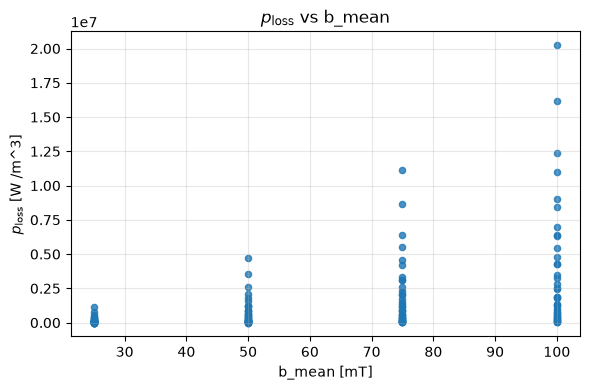

In [4]:
# Quick plotting showcase using DataPlot-loaded data
if dp.input_columns() and dp.output_columns():
    x_col = dp.input_columns()[6]
    y_col = dp.output_columns()[0]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(dp.combined_df[x_col], dp.combined_df[y_col], s=20, alpha=0.8)
    ax.set_xlabel(dp.format_axis_label(x_col))
    ax.set_ylabel(dp.format_axis_label(y_col))
    ax.set_title(f"{dp.get_label(y_col)} vs {dp.get_label(x_col)}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Need at least one input and one output column to plot.")

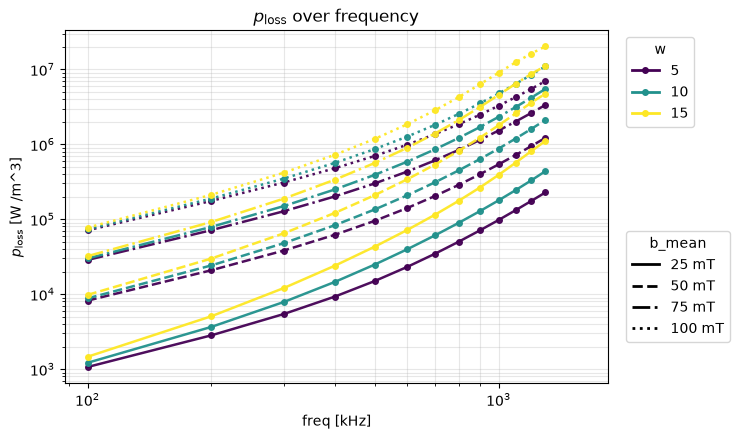

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
dp.y_over_x_with_color_and_style(
    ax=ax,
    y_col="p_loss",
    x_col="freq",
    color_col="w",
    style_col="b_mean"
)
plt.tight_layout()
plt.show()